# Lab: Fraud Detection in Wine Dataset using SVM with Grid Search

In this lab, you will be working on a dataset that contains wine types and their quality, classified as either "Legit" or "Fraud." Your task is to perform classification using Support Vector Machines (SVM) with hyperparameter tuning. You will complete several tasks to clean, preprocess, and analyze the data. Finally, you’ll evaluate the model's performance.

## Goal: 
To understand how to apply classification algorithms and perform model evaluation on imbalanced datasets.

## Dataset: wine_fraud.csv
This dataset includes the following columns:
- **type**: The type of wine (red or white).
- **quality**: The classification of the wine (Legit or Fraud).

## Task 1: Load the Dataset and Display the First Few Rows
**Instruction**: Load the dataset `wine_fraud.csv` into a DataFrame using Pandas and display the first five rows of data.

```python

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/wine_fraud.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


## Task 2: Explore the Target Variable (quality)

**Instruction**: Check the unique values in the target column `quality` to understand the classification types.

**Hint**: Use `.unique()` to display the distinct values in the column.

In [3]:
unique = df['quality'].unique()

print(unique)

['Legit' 'Fraud']


## Task 3: Plot the Distribution of Legit vs. Fraud Wines
**Instruction**: Create a countplot to display the number of wines classified as "Legit" vs. "Fraud."

**Hint**: Use Seaborn’s `countplot()` function.

<Axes: xlabel='quality', ylabel='count'>

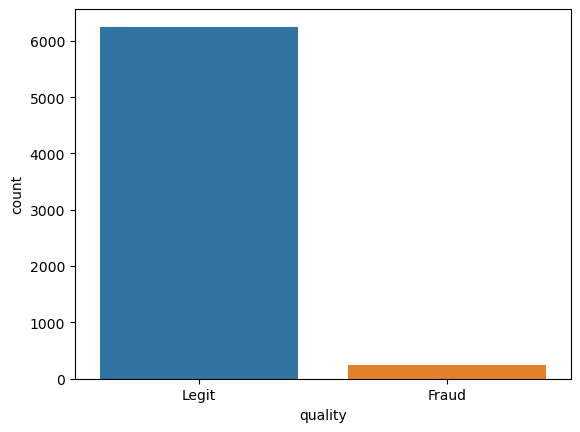

In [4]:
import seaborn as sns

sns.countplot(x='quality', data=df)

## Task 4: Create a Countplot of Wine Type and Quality
**Instruction**: Plot a countplot to show the distribution of wine type (red or white) and classify them by "Legit" or "Fraud" using hue.

<Axes: xlabel='type', ylabel='count'>

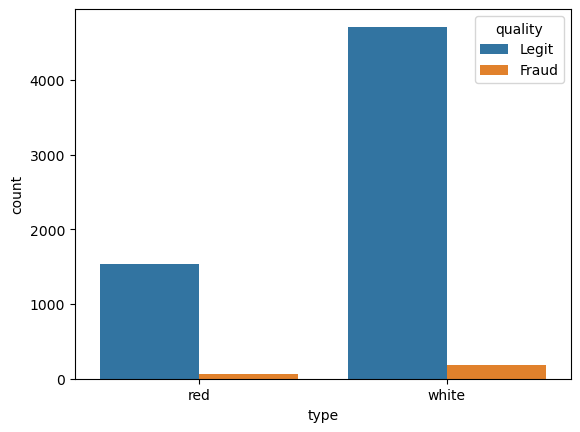

In [6]:
sns.countplot(x='type', hue='quality', data=df)

## Task 5: Calculate the Percentage of Fraud in Red and White Wines
**Instruction**: Calculate the percentage of wines labeled as "Fraud" for both red and white wines and print out the percentage for each wine type.

**Hint**: Filter the dataset by type and calculate the percentage of fraud cases for each subset.


In [84]:
df_red = df.loc[df['type'] == 'red', ['type', 'quality']]
count_red = round(df_red['quality'].value_counts(normalize=True) * 100, 2)
print(f'The percentages for red wine: \n{count_red}')

The percentages for red wine: 
quality
Legit    96.06
Fraud     3.94
Name: proportion, dtype: float64


In [85]:
df_white = df.loc[df['type'] == 'white', ['type', 'quality']]
count_white = round(df_white['quality'].value_counts(normalize=True) * 100, 2)
print(f'The percentages for white wine: \n{count_white}')

The percentages for white wine: 
quality
Legit    96.26
Fraud     3.74
Name: proportion, dtype: float64


## Task 6: Convert the Quality Column into a Numeric Format
**Instruction**: Convert the target variable `quality` from "Legit" and "Fraud" to 0 and 1, respectively, for the classification task.

In [63]:
df_encode = pd.get_dummies(df, columns=['quality'], dtype='int')

df_encode

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,quality_Fraud,quality_Legit
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,red,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,red,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,red,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,red,0,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,red,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,white,0,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,white,0,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,white,0,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,white,0,1


## Task 7: Convert the Type Column into Dummy Variables
**Instruction**: Convert the categorical column `type` into numerical values using Pandas’ `get_dummies()` function.

**Hint**: Use `drop_first=True` to avoid the dummy variable trap.

In [61]:
df_type_encode = pd.get_dummies(df, columns=['type'], drop_first=True, dtype='int')

df_type_encode

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,Legit,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,Legit,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,Legit,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,Legit,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,Legit,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,Legit,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,Legit,1


## Task 8: Split the Dataset into Features and Target Variables
**Instruction**: Separate the features (X) from the target variable (y). Drop the `quality` column from X, and assign y to the Fraud column.

In [67]:
X = df_type_encode.drop('quality', axis=1)
y = df_type_encode['quality']

## Task 9: Train-Test Split and Data Scaling
**Instruction**: Split the dataset into training and testing sets using an 80-20 split and random_state=42 </br>Then, use `StandardScaler` to scale the features in both the training and testing sets.

**Hint**: Use `train_test_split` from Scikit-learn.

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

print(f'X_train: \n{X_train}')
print(f'X_test: \n{X_test}')

X_train: 
[[-0.46822898 -0.59951186  0.20546655 ... -1.0832659   0.01376574
   0.56512866]
 [ 0.85149992 -0.35284877  1.10406349 ...  0.59857677  1.60871671
  -1.76950857]
 [ 0.38571325  2.32961232 -2.14471006 ...  0.26220824  1.10504798
  -1.76950857]
 ...
 [-0.62349121  0.20214318 -0.83137607 ... -0.67962366 -0.82568214
   0.56512866]
 [-0.54586009 -0.47618032  1.24230917 ... -0.41052883 -0.82568214
   0.56512866]
 [-0.00244231  1.74378748 -1.79909585 ...  0.06038712 -0.82568214
  -1.76950857]]
X_test: 
[[-0.19881797 -1.03269521  2.89842878 ... -1.01918451  1.39911755
   0.59630422]
 [ 0.32850455  1.6721092  -0.6913277  ... -0.55058209 -0.52157659
  -1.67699634]
 [-0.34948155  0.23338345  0.1891786  ... -0.6175253   1.23210067
   0.59630422]
 ...
 [-0.50014513 -1.09024424  0.25690986 ...  1.45771398  1.56613443
   0.59630422]
 [-0.50014513  0.23338345  0.46010362 ...  0.25273634 -0.9391188
   0.59630422]
 [ 0.10250918 -1.09024424 -0.28494018 ... -0.6844685  -1.52367788
   0.59630422]

## Task 10: Train an SVM Model with Grid Search
**Instruction**: Use `GridSearchCV` to tune the SVM hyperparameters (C and gamma). Evaluate the best model using a confusion matrix and classification report.

- This code below uses GridSearchCV to find the best hyperparameters (C and gamma) for the SVM model and then evaluates the model using a confusion matrix and classification report.

In [73]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define parameter grid
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto']}

In [74]:
# Perform Grid Search with SVM
grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10],
                         'gamma': ['scale', 'auto']})

In [75]:
# Get the best parameters
print("Best Parameters from GridSearchCV:")
print(grid.best_params_)

Best Parameters from GridSearchCV:
{'C': 10, 'gamma': 'scale'}


In [76]:
# Make predictions using the best model
grid_predictions = grid.predict(X_test)

#### Print the Confusion Matrix

In [79]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, grid_predictions))

Confusion Matrix:
[[  26   23]
 [ 116 1135]]


#### Print the Classification Report

In [80]:
print('Classification Report:')
print(classification_report(y_test, grid_predictions))

Classification Report:
              precision    recall  f1-score   support

       Fraud       0.18      0.53      0.27        49
       Legit       0.98      0.91      0.94      1251

    accuracy                           0.89      1300
   macro avg       0.58      0.72      0.61      1300
weighted avg       0.95      0.89      0.92      1300



### Explain the classification report result. What do the numbers tell you?

Precision: Accuracy of positive predictions.
    Fraud: Only 18% of the fraud predictions were correct.
    Legit: Suggests high reliability, 98% of the predicted legit cases being correct.

Recall: Model's ability to fin all the relevant cases.  How many positive were identified correctly.
    Fraud: The model only caught 53% of all actual fraud instances.
    Legit: 91% of actual legit cases were correctly identified.

F1-Score: Harmonic mean of precision and recall.  It provides a balance between the two metrics.
    Fraud: 0.27 shows a poor balance, indicating the model struggles with fraud classification.
    Legit: 0.94 denotes excellent performance in identifying legit cases.
    
Support: Gives the number of actual occurenences of each class in the dataset.
    Fraud: 49
    LegitL 1251
The support indicates an imbalanced dataset, with many more legit instances than fraud.

Total Accuracy: The model correctly classified 89% of all cases.

Macro Average: Averages the metrics classes without considering the support.  It shows the model's average performance on each class.

Weighted Average: Averages the metrics with consideration of the support of each class.  It demonstrates the model's performance overall, which is skewed by the larger number of legit cases.

The model shows strong performance in identifying legit cases but struggles significantly with fraud detection.  Improving the precision and recall for the fraud class could enhance the robustness of the classification model.

## Critical Thinking Question
**Question**: Based on the results of the classification report, how well did the model handle the imbalanced dataset? 

Overall the model did not handle the imbalanced dataset well.  The low precision and recall for the minority class, fraud, indicates the model struggles with these instances, pointing towards a bias.  The F-1 score not being balanced also indicated the model is biased towards the majority class.